# Uniform Sampling on a Semi-Infinite Domain

This notebook generates uniformly sampled observations, loads the tuned semi-infinite KAN checkpoint, and creates field and prediction-error figures.

## 1. Imports and setup

In [26]:
import numpy as np

In [27]:
from pathlib import Path
import sys
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import torch

notebook_dir = Path.cwd().resolve()
repo_root = next((path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()), notebook_dir)
utilities_dir = repo_root / "utils"
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import pinns_semi_infinite
import semi_infinite
reload(pinns_semi_infinite)
reload(semi_infinite)

from pinns_semi_infinite import build_models_KAN, set_seed
from semi_infinite import (
    analytical_solution_semi_inf,
    coefficient_semi_inf,
    evaluate_model_semi_inf,
    generate_dataset_semi_inf,
)

set_seed(2)
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Generate uniform observations and evaluation data

In [28]:
(X_obs, U_obs, X_obs_k, K_obs, X_pde, F_pde, X, Y, U, K) = generate_dataset_semi_inf(
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    train_domain=(-5.0, 5.0, -5.0, 0.0),
    eval_domain=(-10.0, 10.0, -10.0, 0.0),
    sampling="uniform",
    n_obs_u=100,
    n_boundary_u=10,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=2,
)

boundary_mask = X_obs[:, 1] == 0
print(f"Interior u observations: {len(X_obs) - boundary_mask.sum().item()}")
print(f"Top-boundary u observations: {boundary_mask.sum().item()}")
print(f"Total u observations: {len(X_obs)}")

Interior u observations: 100
Top-boundary u observations: 10
Total u observations: 110


## 3. Load the trained semi-infinite KAN models

In [29]:
model_u, model_k = build_models_KAN(
    device=device,
    hidden_layers=3,
    hidden_units=25,
    grid_size=5,
    spline_order=3,
)

weights_path = repo_root / "main" / "simple_prediction" / "results" / "pikan_semi_infinite_uniform_weights.pt"
checkpoint = torch.load(weights_path, map_location=device)
model_u.load_state_dict(checkpoint["model_u"])
model_k.load_state_dict(checkpoint["model_k"])
print(f"Loaded uniform-sampling checkpoint: {weights_path}")

Loaded uniform-sampling checkpoint: /home/orincon/unbounded-domains/main/simple_prediction/results/pikan_semi_infinite_uniform_weights.pt


## 4. Evaluate the uniform-sampling case

In [30]:
results = evaluate_model_semi_inf(
    model_u=model_u,
    model_k=model_k,
    analytical_solution=analytical_solution_semi_inf,
    coefficient=coefficient_semi_inf,
    X_obs=X_obs,
    X_obs_k=X_obs_k,
    train_domain=(-5.0, 5.0, -5.0, 0.0),
    eval_domain=(-10.0, 10.0, -10.0, 0.0),
    n_grid=400,
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    device=device,
    plot=False,
    verbose=True,
    save_results=False,
)

Semi-infinite-domain spatial generalization (MAE)
u (global): 2.890e-02
k (global): 1.577e-01
u (inside): 3.997e-03
k (inside): 1.250e-03
u (outside): 3.720e-02
k (outside): 2.098e-01


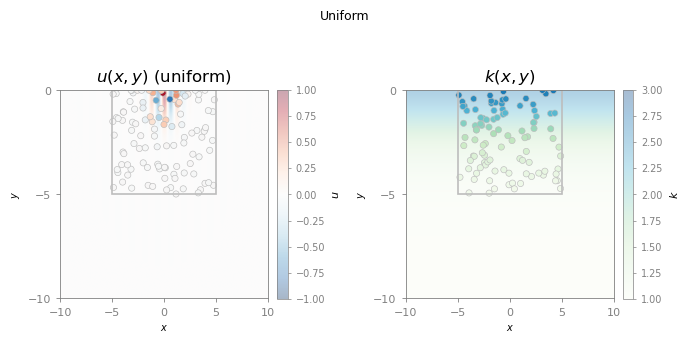

Sampling plot saved to: /home/orincon/unbounded-domains/main/03_sampling_approximation/results/uniform_semi_infinite_spatial_generalization.pdf


In [31]:
train_xmin, train_xmax, train_ymin, train_ymax = (-5.0, 5.0, -5.0, 0.0)
eval_xmin, eval_xmax, eval_ymin, eval_ymax = (-10.0, 10.0, -10.0, 0.0)
extent = [eval_xmin, eval_xmax, eval_ymin, eval_ymax]
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4))
field_plots = [
    (U, X_obs, U_obs, r"$u(x,y)$ (uniform)", "RdBu_r", -1, 1, r"$u$", 7),
    (K, X_obs_k, K_obs, r"$k(x,y)$", "GnBu", 1, 3, r"$k$", 7),
]
for axis, (field, observations, values, title, cmap, vmin, vmax, colorbar_label, fontsize) in zip(axes, field_plots):
    image = axis.imshow(field, extent=extent, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.35, aspect="auto")
    points = observations.detach().cpu().numpy()
    axis.scatter(points[:, 0], points[:, 1], c=values.detach().cpu().numpy().ravel(), cmap=cmap, vmin=vmin, vmax=vmax, s=20, edgecolors="#BDBDBD", linewidths=0.45)
    axis.add_patch(plt.Rectangle((train_xmin, train_ymin), train_xmax - train_xmin, train_ymax - train_ymin, fill=False, edgecolor="#BDBDBD", linewidth=1.2))
    axis.set_xlim(eval_xmin, eval_xmax)
    axis.set_ylim(eval_ymin, eval_ymax)
    axis.set_title(title)
    axis.set_xlabel("$x$", fontsize=7)
    axis.set_ylabel("$y$", fontsize=7)
    axis.set_box_aspect(1)
    axis.set_xticks([eval_xmin, -5, 0, 5, eval_xmax])
    axis.set_yticks([eval_ymin, -5, 0])
    axis.tick_params(axis="both", labelsize=8, colors="gray", length=3, width=0.6)
    for spine in axis.spines.values():
        spine.set_color("gray")
        spine.set_linewidth(0.6)
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.set_label(colorbar_label, fontsize=8)
    colorbar.ax.tick_params(labelsize=7, colors="gray", length=2, width=0.5)
    colorbar.outline.set_edgecolor("gray")
    colorbar.outline.set_linewidth(0.5)
fig.suptitle("Uniform", fontsize=9, y=1.02)
plt.tight_layout()

plot_path = repo_root / "main" / "03_sampling_approximation" / "results" / "uniform_semi_infinite_spatial_generalization.pdf"
plt.show()

plot_path.parent.mkdir(parents=True, exist_ok=True)
print(f"Sampling plot saved to: {plot_path}")
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

Observed maxima: u error=0.6749, k error=0.8427
Manual color limits: u error=0.60, k error=0.80
Prediction/error plot saved to: /home/orincon/unbounded-domains/main/03_sampling_approximation/figures/uniform_semi_infinite_prediction_errors.pdf


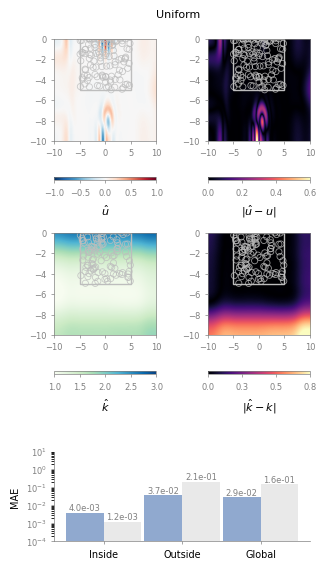

In [45]:
U_pred, K_pred = results["U_pred"], results["K_pred"]
error_u, error_k = results["error_u"], results["error_k"]

# Keep these limits identical to the Gaussian semi-infinite figure.
u_error_vmax = 0.6
k_error_vmax = 0.8
print(f"Observed maxima: u error={np.nanmax(error_u):.4f}, k error={np.nanmax(error_k):.4f}")
print(f"Manual color limits: u error={u_error_vmax:.2f}, k error={k_error_vmax:.2f}")

# --------------------------------------------------
# Figure and layout
# --------------------------------------------------
fig = plt.figure(figsize=(3.3, 7.0))

grid = fig.add_gridspec(
    5,
    2,
    height_ratios=[1.0, 0.08, 1.0, 0.42, 0.5],
    hspace=0.0,
    wspace=0.50,
)

ax_u, ax_u_error = (
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
)

ax_k, ax_k_error = (
    fig.add_subplot(grid[2, 0]),
    fig.add_subplot(grid[2, 1]),
)

ax_error = fig.add_subplot(grid[4, :])


# --------------------------------------------------
# Colors
# --------------------------------------------------
axis_gray = "#808080"
observation_gray = "#BDBDBD"


# --------------------------------------------------
# Prediction and error fields
# --------------------------------------------------
images = [
    (
        ax_u,
        U_pred,
        "RdBu_r",
        -1,
        1,
        r"$\hat{u}$",
    ),
    (
        ax_u_error,
        error_u,
        "magma",
        0,
        u_error_vmax,
        r"$|\hat{u}-u|$",
    ),
    (
        ax_k,
        K_pred,
        "GnBu",
        1,
        3,
        r"$\hat{k}$",
    ),
    (
        ax_k_error,
        error_k,
        "magma",
        0,
        k_error_vmax,
        r"$|\hat{k}-k|$",
    ),
]


for axis, field, cmap, vmin, vmax, colorbar_label in images:

    image = axis.imshow(
        field,
        extent=[-10, 10, -10, 0],
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    axis.set_box_aspect(1)

    axis.set_xlim(-10, 10)
    axis.set_ylim(-10, 0)

    # Training domain
    axis.add_patch(
        plt.Rectangle(
            (-5, -5),
            10,
            5,
            fill=False,
            edgecolor=observation_gray,
            linewidth=1.0,
        )
    )

    # --------------------------------------------------
    # Colorbar
    # --------------------------------------------------
    colorbar = fig.colorbar(
        image,
        ax=axis,
        orientation="horizontal",
        fraction=0.028,
        pad=0.20,
        aspect=30,
    )

    if axis is ax_k_error:
        colorbar.set_ticks(np.linspace(0, k_error_vmax, 4))
        colorbar.ax.set_xticklabels(
            [f"{tick:.1f}" for tick in np.linspace(0, k_error_vmax, 4)]
        )

    if axis is ax_u_error:
        colorbar.set_ticks(np.linspace(0, u_error_vmax, 4))
        colorbar.ax.set_xticklabels(
            [f"{tick:.1f}" for tick in np.linspace(0, u_error_vmax, 4)]
        )

    colorbar.set_label(
        colorbar_label,
        fontsize=8,
        color="black",
    )

    colorbar.ax.tick_params(
        labelsize=6,
        colors=axis_gray,
        length=2,
        width=0.5,
    )

    # Colorbar spines
    for spine in colorbar.ax.spines.values():
        spine.set_color(axis_gray)
        spine.set_linewidth(0.5)


# --------------------------------------------------
# Observation points
# --------------------------------------------------
for axis, observations in (
    (ax_u, X_obs),
    (ax_u_error, X_obs),
    (ax_k, X_obs_k),
    (ax_k_error, X_obs_k),
):

    points = observations.detach().cpu().numpy()

    axis.scatter(
        points[:, 0],
        points[:, 1],
        facecolors="none",
        edgecolors=observation_gray,
        s=20,
        alpha=0.8,
        linewidths=0.6,
    )


# --------------------------------------------------
# Regional errors
# --------------------------------------------------
regions = [
    "Inside",
    "Outside",
    "Global",
]

u_errors = [
    results["err_u_inside"],
    results["err_u_outside"],
    results["err_u_global"],
]

k_errors = [
    results["err_k_inside"],
    results["err_k_outside"],
    results["err_k_global"],
]


positions = np.arange(len(regions))
width = 0.48


bars_u = ax_error.bar(
    positions - width / 2,
    u_errors,
    width=width,
    color="#2255a080",
    label=r"$u$",
)

bars_k = ax_error.bar(
    positions + width / 2,
    k_errors,
    width=width,
    color="#d6d6d683",
    label=r"$k$",
)


# --------------------------------------------------
# Error plot formatting
# --------------------------------------------------
ax_error.set_yscale("log")
ax_error.set_ylim(1e-4, 10)

ax_error.set_xticks(positions)
ax_error.set_xticklabels(
    regions,
    fontsize=7,
)

# Hide top and right spines
ax_error.spines["top"].set_visible(False)
ax_error.spines["right"].set_visible(False)

# Make remaining spines gray
ax_error.spines["left"].set_color(axis_gray)
ax_error.spines["bottom"].set_color(axis_gray)

ax_error.spines["left"].set_linewidth(0.5)
ax_error.spines["bottom"].set_linewidth(0.5)


# --------------------------------------------------
# Legend
# --------------------------------------------------
# ax_error.legend(
#     fontsize=7,
#     frameon=False,
#     loc="lower center",
#     bbox_to_anchor=(0.5, 0.8),
#     ncol=2,
#     borderaxespad=0,
# )




# --------------------------------------------------
# Error values above bars
# --------------------------------------------------
for bar, value in zip(
    [*bars_u, *bars_k],
    [*u_errors, *k_errors],
):

    ax_error.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1e}",
        ha="center",
        va="bottom",
        fontsize=6,
        color="gray",
    )


# --------------------------------------------------
# Gray axes, ticks, labels, and spines
# --------------------------------------------------
for axis in (
    ax_u,
    ax_u_error,
    ax_k,
    ax_k_error,
    ax_error,
):

    axis.tick_params(
        axis="both",
        labelsize=6,
        colors=axis_gray,
        length=2,
        width=0.5,
    )

    for spine in axis.spines.values():

        if spine.get_visible():
            spine.set_color(axis_gray)
            spine.set_linewidth(0.5)

    axis.xaxis.label.set_color(axis_gray)
    axis.yaxis.label.set_color(axis_gray)

# Keep the region labels black
ax_error.set_xticklabels(
    regions,
    fontsize=7,
    color="black",
)

# --------------------------------------------------
# y-label
# --------------------------------------------------
ax_error.set_ylabel(
    "MAE",
    fontsize=7,
    color="black",
)
# --------------------------------------------------
# Title
# --------------------------------------------------
fig.suptitle(
    "Uniform",
    fontsize=8,
    y=0.87,
)


# --------------------------------------------------
# Save figure
# --------------------------------------------------
plot_path = (
    repo_root
    / "main"
    / "03_sampling_approximation"
    / "figures"
    / "uniform_semi_infinite_prediction_errors.pdf"
)

plot_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"Prediction/error plot saved to: {plot_path}"
)

plt.show()